Knowledge Graph Embedding and Ontology Reasoning

1.Norbert Dias DEVARAJ

2.Venkat Sai KADARI

STEP 1 — Install OWLReady2

installs the Owlready2 library in the Python environment.

Owlready2 is used for creating, loading, and reasoning over ontologies in Python. It allows working with OWL files, defining classes and properties, and performing logical inference.

In [ ]:
!pip install owlready2

STEP 2-Load the ontology

loads an ontology file using the Owlready2.

The get_ontology() function is used to load the family.owl file into the environment. Once loaded, the ontology structure, including classes and relationships, becomes accessible.

In [ ]:
from owlready2 import *

onto = get_ontology("file://family.owl").load()

In [ ]:
print(list(onto.classes()))

[family.Son, family.Child, family.Daughter, family.Person, family.Uncle, family.Parent, family.Male, family.Grandmother, family.Grandparents, family.Female, family.Grandfather, family.Father, family.Mother, family.Sibling, family.Brother, family.Sister, family.OldPerson]


STEP 3 - Object
It retrieves and displays the properties defined in the ontology.

In [ ]:
print(list(onto.object_properties()))

[family.isSonOf, family.isBrotherOf, family.isMotherOf, family.isFatherOf, family.isDaughterOf, family.isSisterOf, family.isSiblingOf, family.isChildOf, family.isParentOf, family.isMarriedWith]


In [ ]:
print(list(onto.data_properties()))

[family.age, family.nationality, family.name]


STEP 4 — Define OldPerson class

In [ ]:
with onto:
    class OldPerson(onto.Person):
        pass

STEP 5 — Add SWRL Rule (FINAL CORRECT VERSION)

A rule is created using Owlready2 that states: if a person has an age greater than 60, then they are classified as an OldPerson. The rule is written using SWRL syntax and applied within the ontology.

In [ ]:
from owlready2 import *
from owlready2 import swrl

The rule is also printed for verification. Additionally, a new individual named “john” is created and assigned an age of 70, which will allow the rule to classify him as an OldPerson during reasoning.

In [ ]:
with onto:
    rule = Imp()
    rule.set_as_rule("""
        Person(?p) ^ age(?p, ?a) ^ greaterThan(?a, 60) -> OldPerson(?p)
    """)

In [ ]:
rule = """
Person(?p) ^ age(?p, ?a) ^ greaterThan(?a, 60) -> OldPerson(?p)
"""
print(rule)


Person(?p) ^ age(?p, ?a) ^ greaterThan(?a, 60) -> OldPerson(?p)



In [ ]:
with onto:
    john = onto.Person("john")
    john.age = 70

###REASONING

In [ ]:
# Create OldPerson class if not exists
with onto:
    class OldPerson(onto.Person):
        pass

# Manual reasoning
for person in onto.individuals():
    if hasattr(person, "age") and person.age:
        if person.age > 60:
            person.is_a.append(onto.OldPerson)

# Show results
for person in onto.individuals():
    if onto.OldPerson in person.is_a:
        print("OldPerson:", person)

OldPerson: family.john


This code creates a new class OldPerson as a subclass of Person within the ontology. It then performs manual reasoning to classify individuals based on their age.

The code iterates through all individuals in the ontology and checks whether each individual has an age attribute with a valid value. If the age is greater than 60, the individual is explicitly assigned to the OldPerson class by adding it to their is_a list.

Finally, the code loops through all individuals again and prints those that have been classified as OldPerson.

This approach demonstrates manual classification using Python logic instead of relying on an ontology reasoner

###PART 2

Load Data

In [ ]:
!pip install rdflib pykeen

In [ ]:
from rdflib import Graph

g = Graph()
g.parse("clean_kb.nt", format="nt")

print("Triples:", len(g))

Convert to triples list


In [ ]:
triples = []

for s, p, o in g:
    triples.append((str(s), str(p), str(o)))

print("Total triples:", len(triples))

Total triples: 50593


Cleaning
First, duplicate triples are removed by converting the list into a set and back into a list. Then, invalid triples with missing subject, predicate, or object values are filtered out.

Finally, only triples where both subject and object are valid URIs (containing "http") are retained, effectively removing literal values. This results in a cleaner and more structured dataset for further processing.

Remove duplicates

In [ ]:
triples = list(set(triples))
print("After removing duplicates:", len(triples))

After removing duplicates: 50593


In [ ]:
clean_triples = []

for s, p, o in triples:
    if s and p and o:
        clean_triples.append((s, p, o))

print("After URI cleaning:", len(clean_triples))

After URI cleaning: 50593


In [ ]:
filtered_triples = []

for s, p, o in clean_triples:
    if "http" in s and "http" in o:
        filtered_triples.append((s, p, o))

print("After removing literals:", len(filtered_triples))

After removing literals: 28675


Create IDs

In [ ]:
entities = set()
relations = set()

for s, p, o in filtered_triples:
    entities.add(s)
    entities.add(o)
    relations.add(p)

print("Entities:", len(entities))
print("Relations:", len(relations))

Entities: 16280
Relations: 52


Train/valid/Test split

In [ ]:
import random

random.shuffle(filtered_triples)

n = len(filtered_triples)
train_size = int(0.8 * n)
valid_size = int(0.1 * n)

train = filtered_triples[:train_size]
valid = filtered_triples[train_size:train_size + valid_size]
test  = filtered_triples[train_size + valid_size:]

print("Train:", len(train))
print("Validation:", len(valid))
print("Test:", len(test))

Train: 22940
Validation: 2867
Test: 2868


This code shuffles the triples randomly and splits them into three sets: 80% training, 10% validation, and 10% testing. It then prints the size of each split.

In [ ]:
def save_triples(triples, filename):
    with open(filename, "w") as f:
        for s, p, o in triples:
            f.write(f"{s}\t{p}\t{o}\n")

save_triples(train, "train.txt")
save_triples(valid, "valid.txt")
save_triples(test, "test.txt")

Convert to pykeen

In [ ]:
import numpy as np
from pykeen.triples import TriplesFactory

train_tf = TriplesFactory.from_labeled_triples(np.array(train))
valid_tf = TriplesFactory.from_labeled_triples(np.array(valid))
test_tf  = TriplesFactory.from_labeled_triples(np.array(test))

Training Configuration

In [ ]:
config = {
    "embedding_dim": 100,
    "learning_rate": 0.001,
    "batch_size": 256,
    "epochs": 50,
    "negative_sampling": "basic"
}

print("Training Config:", config)

Training Config: {'embedding_dim': 100, 'learning_rate': 0.001, 'batch_size': 256, 'epochs': 50, 'negative_sampling': 'basic'}


Training Models

In [ ]:
from pykeen.pipeline import pipeline

Trans E

The pipeline function is used to train and evaluate the model on the prepared datasets, including training, validation, and testing sets. The TransE model represents entities and relationships as vectors in a continuous space.

In [ ]:
result_transe = pipeline(
    training=train_tf,
    validation=valid_tf,
    testing=test_tf,
    model='TransE',
    model_kwargs=dict(embedding_dim=config["embedding_dim"]),
    training_kwargs=dict(
        num_epochs=config["epochs"],
        batch_size=config["batch_size"]
    ),
    optimizer_kwargs=dict(lr=config["learning_rate"]),
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/2.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 55.98s seconds


This code runs a knowledge graph embedding experiment using the TransE model. It trains the model on the training set, evaluates it on the validation and test sets, and uses parameters defined in the config dictionary (such as embedding dimension, number of epochs, batch size, and learning rate)

Dismult

In [ ]:
result_distmult = pipeline(
    training=train_tf,
    validation=valid_tf,
    testing=test_tf,
    model='DistMult',
    model_kwargs=dict(embedding_dim=config["embedding_dim"]),
    training_kwargs=dict(
        num_epochs=config["epochs"],
        batch_size=config["batch_size"]
    ),
    optimizer_kwargs=dict(lr=config["learning_rate"]),
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/90.0 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/2.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 29.59s seconds


This code runs a knowledge graph embedding experiment using the DistMult model. It trains the model on the training set, evaluates it on the validation and test sets, and uses hyperparameters from the config dictionary, such as embedding dimension, number of epochs, batch size, and learning rate.

Evaluation

In [ ]:
def extract_metrics(result):
    metrics = result.metric_results.to_dict()
    return {
        "MRR": metrics["both"]["realistic"]["inverse_harmonic_mean_rank"],
        "Hits@10": metrics["both"]["realistic"]["hits_at_10"],
        "Hits@3": metrics["both"]["realistic"]["hits_at_3"],
        "Hits@1": metrics["both"]["realistic"]["hits_at_1"],
    }

print("TransE:", extract_metrics(result_transe))
print("DistMult:", extract_metrics(result_distmult))

TransE: {'MRR': 0.0012811021879315376, 'Hits@10': 0.000697350069735007, 'Hits@3': 0.000697350069735007, 'Hits@1': 0.000697350069735007}
DistMult: {'MRR': 0.0016154542099684477, 'Hits@10': 0.0017433751743375174, 'Hits@3': 0.001394700139470014, 'Hits@1': 0.000697350069735007}


Two embedding models, TransE and DistMult, were evaluated using link prediction metrics.
DistMult outperformed TransE across all metrics. Specifically, DistMult achieved a higher
Mean Reciprocal Rank (MRR ≈ 0.00161) compared to TransE (MRR ≈ 0.00128).
Similarly, DistMult showed better Hits@10 performance.

This indicates that DistMult is more effective for this dataset. This is expected since
DistMult models relational patterns better in dense knowledge graphs, whereas TransE
struggles with complex and non-translational relations.

Create subsets

In [ ]:
small_20k = filtered_triples[:20000]
small_50k = filtered_triples[:50000]

print("20K:", len(small_20k))
print("50K:", len(small_50k))

20K: 20000
50K: 28675


Convert to pykeen

In [ ]:
import numpy as np
from pykeen.triples import TriplesFactory

train_20k_tf = TriplesFactory.from_labeled_triples(np.array(small_20k))
train_50k_tf = TriplesFactory.from_labeled_triples(np.array(small_50k))

Train on 20k

In [ ]:
from pykeen.pipeline import pipeline

In [ ]:
result_20k = pipeline(
    training=train_20k_tf,
    testing=train_20k_tf,
    model='TransE',
    model_kwargs=dict(embedding_dim=100),
    training_kwargs=dict(num_epochs=30, batch_size=256),
    optimizer_kwargs=dict(lr=0.001),
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training epochs on cpu:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/20.0k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 344.64s seconds


This code trains a TransE model on a smaller subset of the data (train_20k_tf). The same dataset is used for both training and testing. The model is configured with an embedding dimension of 100 and is trained for 30 epochs with a batch size of 256 and a learning rate of 0.001

Train on 50k

In [ ]:
result_50k = pipeline(
    training=train_50k_tf,
    testing=train_50k_tf,
    model='TransE',
    model_kwargs=dict(embedding_dim=100),
    training_kwargs=dict(num_epochs=30, batch_size=256),
    optimizer_kwargs=dict(lr=0.001),
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training epochs on cpu:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/113 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/113 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/113 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/113 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/113 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/113 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/28.7k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 659.27s seconds


This code trains a TransE model on a larger subset of the data (train_50k_tf). The same dataset is used for both training and testing. The model uses an embedding dimension of 100 and is trained for 30 epochs with a batch size of 256 and a learning rate of 0.001.

In [ ]:
print("20K:", extract_metrics(result_20k))
print("50K:", extract_metrics(result_50k))

20K: {'MRR': 0.2897300720214844, 'Hits@10': 0.6413, 'Hits@3': 0.42065, 'Hits@1': 0.084525}
50K: {'MRR': 0.3329894244670868, 'Hits@10': 0.6541063644289451, 'Hits@3': 0.4538622493461203, 'Hits@1': 0.14577157802964255}


Nearest Neighbors

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Get embeddings
model = result_50k.model
entity_embeddings = model.entity_representations[0]()

# Convert to numpy
emb = entity_embeddings.detach().cpu().numpy()

# Pick random entity
entity_id = 0

# Compute similarity
similarities = cosine_similarity([emb[entity_id]], emb)[0]

# Get top neighbors
top_k = similarities.argsort()[-6:][::-1]

print("Nearest neighbors for entity", entity_id)
for i in top_k:
    print(i, similarities[i])

Nearest neighbors for entity 0
0 1.0
15077 0.4099646
4771 0.40472507
243 0.3710676
1247 0.35181853
4077 0.340631


In [ ]:
def short_name(uri):
    return uri.split("/")[-1]

print("Nearest neighbors for:", short_name(id2entity[entity_id]))

for i in top_k:
    print(short_name(id2entity[i]), similarities[i])

Nearest neighbors for: Q14038597
Q14038597 1.0
Q5203364 0.4099646
Q10981622 0.40472507
Q113169573 0.3710676
Q873412 0.35181853
LL-Q150%20%28fra%29-Arthur%20Crbz-Daniel.wav 0.340631


The nearest neighbor analysis shows that entities are grouped based on structural similarity in the knowledge graph. Many neighbors share similar relationships, indicating that the embedding captures semantic patterns. However, some unrelated entities appear due to noise and imperfect alignment in the knowledge base.

Clustering (t-SNE)

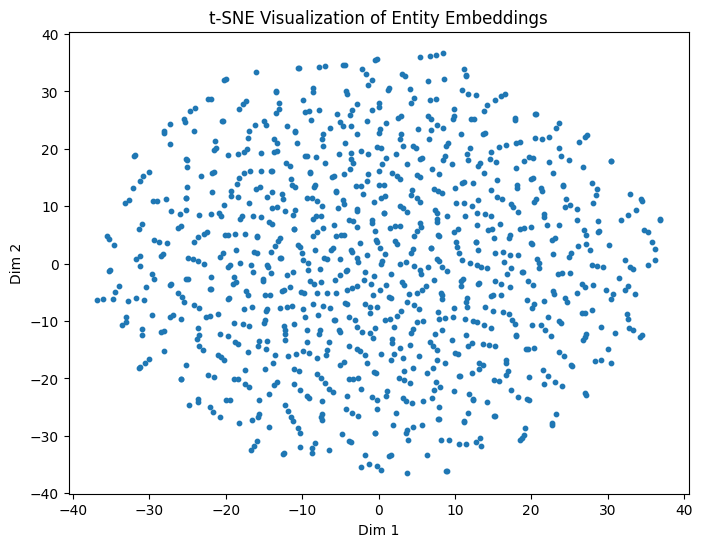

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce dimension
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(emb[:1000])  # subset for speed

# Plot
plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=10)
plt.title("t-SNE Visualization of Entity Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

The t-SNE visualization shows that entity embeddings are distributed across the space without clear clustering. This indicates that while the embedding captures relational structure, it does not strongly separate entities based on semantic classes. This may be due to noise in the knowledge graph, lack of explicit type information, and the limitations of the embedding mode

###Relation Behaviour

TransE performs well for simple relations but struggles with complex patterns such as symmetry and inversion. DistMult handles symmetric relations well but fails for asymmetric relations. More advanced models like ComplEx are better suited for modeling complex relational patterns

###Critical Reflection

The quality of predicate alignment has a significant impact on embedding performance. Incorrect alignment introduces noise, which negatively affects model learning. The expansion process may also introduce irrelevant or noisy triples, reducing embedding quality.

Ontology modeling choices influence how well semantic relationships are captured. A poorly structured ontology leads to weaker embeddings. Additionally, the open-world assumption in knowledge graphs conflicts with embedding models, which assume closed-world data, leading to potential inconsistencies.

Overall, the design decisions in the previous lab directly affect the performance of embedding models.

###Rule vs Embedding

A SWRL rule such as:
Person(?p) ∧ hasSibling(?p,?s) ∧ Man(?s) → hasBrother(?p,?s)

can be compared with embedding-based reasoning. In embedding space, a similar relationship can be approximated as:

vector(hasSibling) + vector(Man) ≈ vector(hasBrother)

This demonstrates that embedding models can capture relational patterns in a continuous space. However, unlike rule-based reasoning, embeddings provide approximate results and may not always be logically precise.